# HealthRisk Prediction - Machine Learning Pipeline
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

/Users/mdarifulamin/PycharmProjects/ml-pipeline-heath-risk_predictor/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/mdarifulamin/PycharmProjects/ml-pipeline-heath-risk_predictor/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Data Loading

In [2]:
# Load dataset
dataset = load_dataset("lvimuth/HealthRisk-1500-Medical-Risk-Prediction")
df = dataset["train"].to_pandas()
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1500, 11)


,Patient_ID,Age,Gender,Symptoms,Medical_History,Medications,Lab_Reports,Lifestyle,Doctor_Notes,Diagnosis,Risk_Level
0,P0001,69,Female,"Memory loss, confusion",Stroke history,Ibuprofen,High blood sugar,Healthy diet,"Reports difficulty breathing, requires further...",Cancer Screening Needed,Medium
1,P0002,61,Male,"Shortness of breath, dizziness",Arthritis,Levothyroxine,High blood pressure,Smoker,"Nausea reported, possible gastrointestinal issue",Respiratory Infection,Medium
2,P0003,29,Male,"Shortness of breath, dizziness",Arthritis,Omeprazole,Irregular heartbeat detected,Drinker,"Sudden weight loss unexplained, requires evalu...",Migraine,Low
3,P0004,63,Male,"High fever, body aches",Asthma,Aspirin,High cholesterol,Active,Mild symptoms but family history is concerning,Arthritis,Medium
4,P0005,46,Female,"Joint pain, swelling",No known history,Omeprazole,High blood sugar,Drinker,"Heart palpitations observed, needs ECG",Arthritis,Medium


## 3. Preprocessing & Feature Engineering

In [3]:
# Feature Engineering: Symptom Count
if 'Symptoms' in df.columns:
    df['Symptom_Count'] = df['Symptoms'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)

# Drop ID, Text, and original Symptoms columns
cols_to_drop = ['Patient_ID', 'Doctor_Notes', 'Symptoms']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# Define Target and Features
target_col = 'Risk_Level'
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print("Features:", X.columns.tolist())
print("Target:", target_col)

Features: ['Age', 'Gender', 'Medical_History', 'Medications', 'Lab_Reports', 'Lifestyle', 'Diagnosis', 'Symptom_Count']
Target: Risk_Level


## 4. Encoding & Splitting

In [4]:
# Encode Target Variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Target Classes: {le.classes_} -> {np.unique(y_encoded)}")

# Identify Numerical and Categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocessing Pipeline for Features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# Transform X
X_processed = preprocessor.fit_transform(X)
print(f"Processed Feature Matrix Shape: {X_processed.shape}")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

Target Classes: ['High' 'Low' 'Medium'] -> [0 1 2]
Processed Feature Matrix Shape: (1500, 50)


## 5. Classical Machine Learning Models

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

results = []

print("Training Classical Models...")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc})
    print(f"{name}: {acc:.4f}")

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)

Training Classical Models...
Logistic Regression: 0.3367
KNN: 0.3300
SVM: 0.3467
Naive Bayes: 0.3467
Decision Tree: 0.3233
Random Forest: 0.3633
Gradient Boosting: 0.3767
AdaBoost: 0.4033
XGBoost: 0.3400


## 6. Deep Learning (PyTorch)

In [6]:
# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Define Model Architecture
class RiskPredictor(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(RiskPredictor, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        x = self.dropout(x)
        x = self.output(x)
        return x

# Initialize Model
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_encoded))
model = RiskPredictor(input_dim, num_classes)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
epochs = 50
model.train()
for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# Evaluation
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs.data, 1)
    nn_acc = accuracy_score(y_test_tensor, predicted)

print(f"PyTorch Neural Network Accuracy: {nn_acc:.4f}")

# Add to results
new_row = pd.DataFrame([{"Model": "Neural Network (PyTorch)", "Accuracy": nn_acc}])
results_df = pd.concat([results_df, new_row], ignore_index=True).sort_values(by='Accuracy', ascending=False)

Epoch [10/50], Loss: 1.0663
Epoch [20/50], Loss: 0.8659
Epoch [30/50], Loss: 0.7174
Epoch [40/50], Loss: 0.8719
Epoch [50/50], Loss: 0.7767
PyTorch Neural Network Accuracy: 0.3467


## 7. Model Evaluation & Comparison

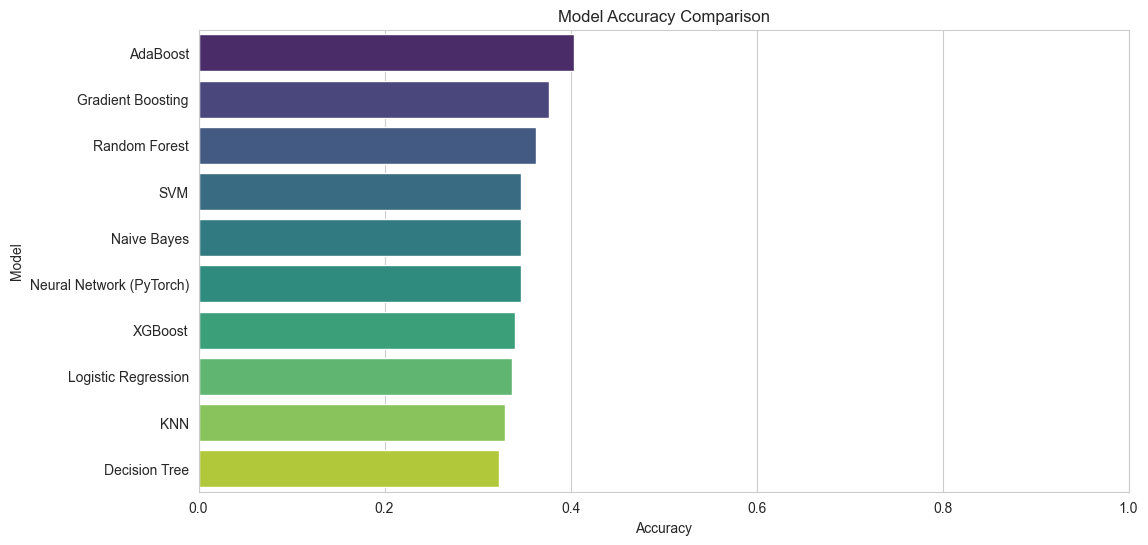

,Model,Accuracy
0,AdaBoost,0.403333
1,Gradient Boosting,0.376667
2,Random Forest,0.363333
3,SVM,0.346667
4,Naive Bayes,0.346667
9,Neural Network (PyTorch),0.346667
5,XGBoost,0.340000
6,Logistic Regression,0.336667
7,KNN,0.330000
8,Decision Tree,0.323333


In [7]:
# Plot Model Performance
plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlim(0, 1.0)
plt.show()

display(results_df)

### 7.1 Best Model Detailed Report

Best Model: AdaBoost

Classification Report:
              precision    recall  f1-score   support

        High       0.44      0.51      0.47       105
         Low       0.41      0.45      0.43        99
      Medium       0.34      0.23      0.27        96

    accuracy                           0.40       300
   macro avg       0.39      0.40      0.39       300
weighted avg       0.39      0.40      0.39       300



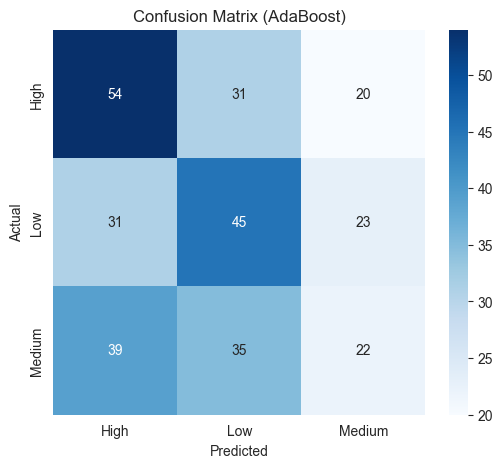

In [8]:
best_model_name = results_df.iloc[0]['Model']
print(f"Best Model: {best_model_name}")

if 'PyTorch' in best_model_name:
    model.eval()
    with torch.no_grad():
        outputs = model(X_test_tensor)
        _, y_pred_best = torch.max(outputs.data, 1)
        y_pred_best = y_pred_best.numpy()
else:
    best_model = models[best_model_name]
    y_pred_best = best_model.predict(X_test)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix ({best_model_name})')
plt.show()